# Prédiction du stress hydrique — exploration
Run `make data preprocess features` first. This notebook reads the pipeline outputs and explores **training observations only**. No conclusions about measured crop stress can be drawn from these modeled labels.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'configs').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from src.utils.config import load_config, get_path
from src.features.build_features import FEATURES
from src.models.common import read_dataset
cfg = load_config()
ARTIFACTS = get_path(cfg, 'artifacts')


## Dimensions, quality and split boundaries
Dataset-level counts are metadata; all distributions below exclude validation/test outcomes.

In [2]:
df, manifest = read_dataset(cfg)
display(manifest['splits'])
training = df.loc[df.split == 'train'].copy()
del df
display(training.shape)
display(training[FEATURES + ['target']].describe().T)
display(training.isna().sum())
display(json.loads((ARTIFACTS / 'data_quality.json').read_text()))

{'test': {'first_target': '2022-11-16',
  'last_target': '2024-05-12',
  'rows': 1074},
 'train': {'first_target': '2016-01-02',
  'last_target': '2021-05-13',
  'rows': 3081},
 'validation': {'first_target': '2021-11-16',
  'last_target': '2022-05-13',
  'rows': 537}}

(3081, 31)

,count,mean,std,min,25%,50%,75%,max
temperature,3081.0,13.637176,3.669860,3.250000,11.090000,13.340000,15.920000,28.090000
temperature_max,3081.0,21.069104,4.887706,5.700000,17.820000,20.860000,24.200000,39.520000
temperature_min,3081.0,8.335430,3.207804,-1.540000,6.210000,8.300000,10.430000,20.290000
precipitation,3081.0,1.964739,6.587944,0.000000,0.000000,0.040000,0.850000,203.270000
humidity,3081.0,65.987605,15.058352,18.580000,56.020000,68.550000,77.370000,94.370000
wind_speed,3081.0,2.188406,0.870816,0.660000,1.590000,1.950000,2.540000,7.540000
solar_radiation,3081.0,16.460932,5.911703,1.970000,12.390000,15.140000,20.960000,31.080000
temperature_range,3081.0,12.733674,3.449850,2.300000,10.470000,13.080000,15.160000,22.560000
vpd_kpa,3081.0,0.570890,0.352699,0.049892,0.316497,0.485831,0.733109,2.758011
et0,3081.0,2.859000,1.277282,0.617127,1.841152,2.509126,3.733882,7.913005


site_id               0
date                  0
target_date           0
split                 0
temperature           0
temperature_max       0
temperature_min       0
precipitation         0
humidity              0
wind_speed            0
solar_radiation       0
temperature_range     0
vpd_kpa               0
et0                   0
rainfall_7d           0
rainfall_30d          0
temperature_7d        0
water_balance_30d     0
precipitation_lag1    0
doy_sin               0
doy_cos               0
crop_age              0
kc                    0
latitude              0
longitude             0
field_capacity        0
wilting_point         0
root_depth_m          0
taw_mm                0
stress_today          0
target                0
dtype: int64

{'duplicates': 0,
 'end': '2024-06-30',
 'missing': {'date': 0,
  'field_capacity': 0,
  'humidity': 0,
  'latitude': 0,
  'longitude': 0,
  'precipitation': 0,
  'site_id': 0,
  'solar_radiation': 0,
  'temperature': 0,
  'temperature_max': 0,
  'temperature_min': 0,
  'wilting_point': 0,
  'wind_speed': 0},
 'radiation_unit': 'MJ/m2/day',
 'rows': 10407,
 'sites': 3,
 'start': '2015-01-01',
 'status': 'passed'}

## Reproducible EDA plots
The same plotting functions run in the script pipeline. No manual output or hardcoded metrics.

{'dataset_rows': 4692,
 'training_rows': 3081,
 'training_target_zero_fraction': 0.4329763063940279,
 'training_target_mean': 0.3471699011115043,
 'outlier_counts': {'temperature': 41,
  'precipitation': 552,
  'humidity': 21,
  'et0': 20,
  'rainfall_30d': 149,
  'target': 0},
 'policy': 'IQR flags are descriptive only. Valid extremes are retained. No validation/test outcome plots are used in exploration.'}

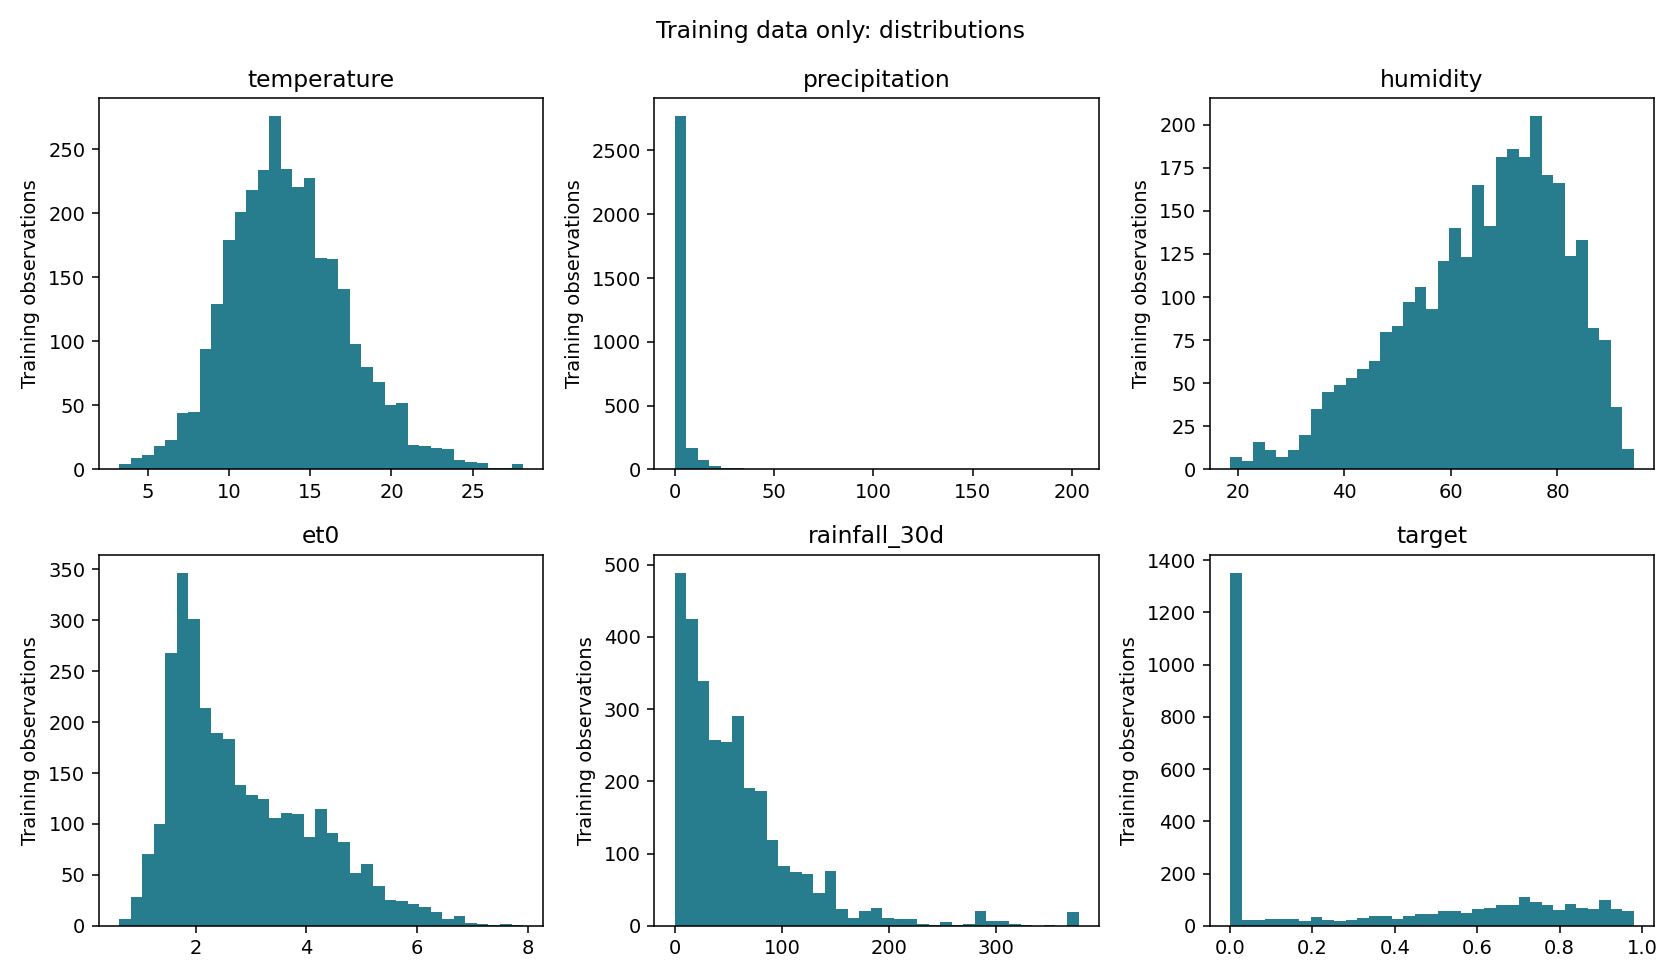

In [3]:
from src.reports import eda
summary = eda(cfg)
display(summary)
display(Image(filename=str(ARTIFACTS / 'eda/distributions.png')))

## Correlations
Static root depth has zero variance, so its correlation is undefined. Correlations combine sites and seasons and do not imply causation.

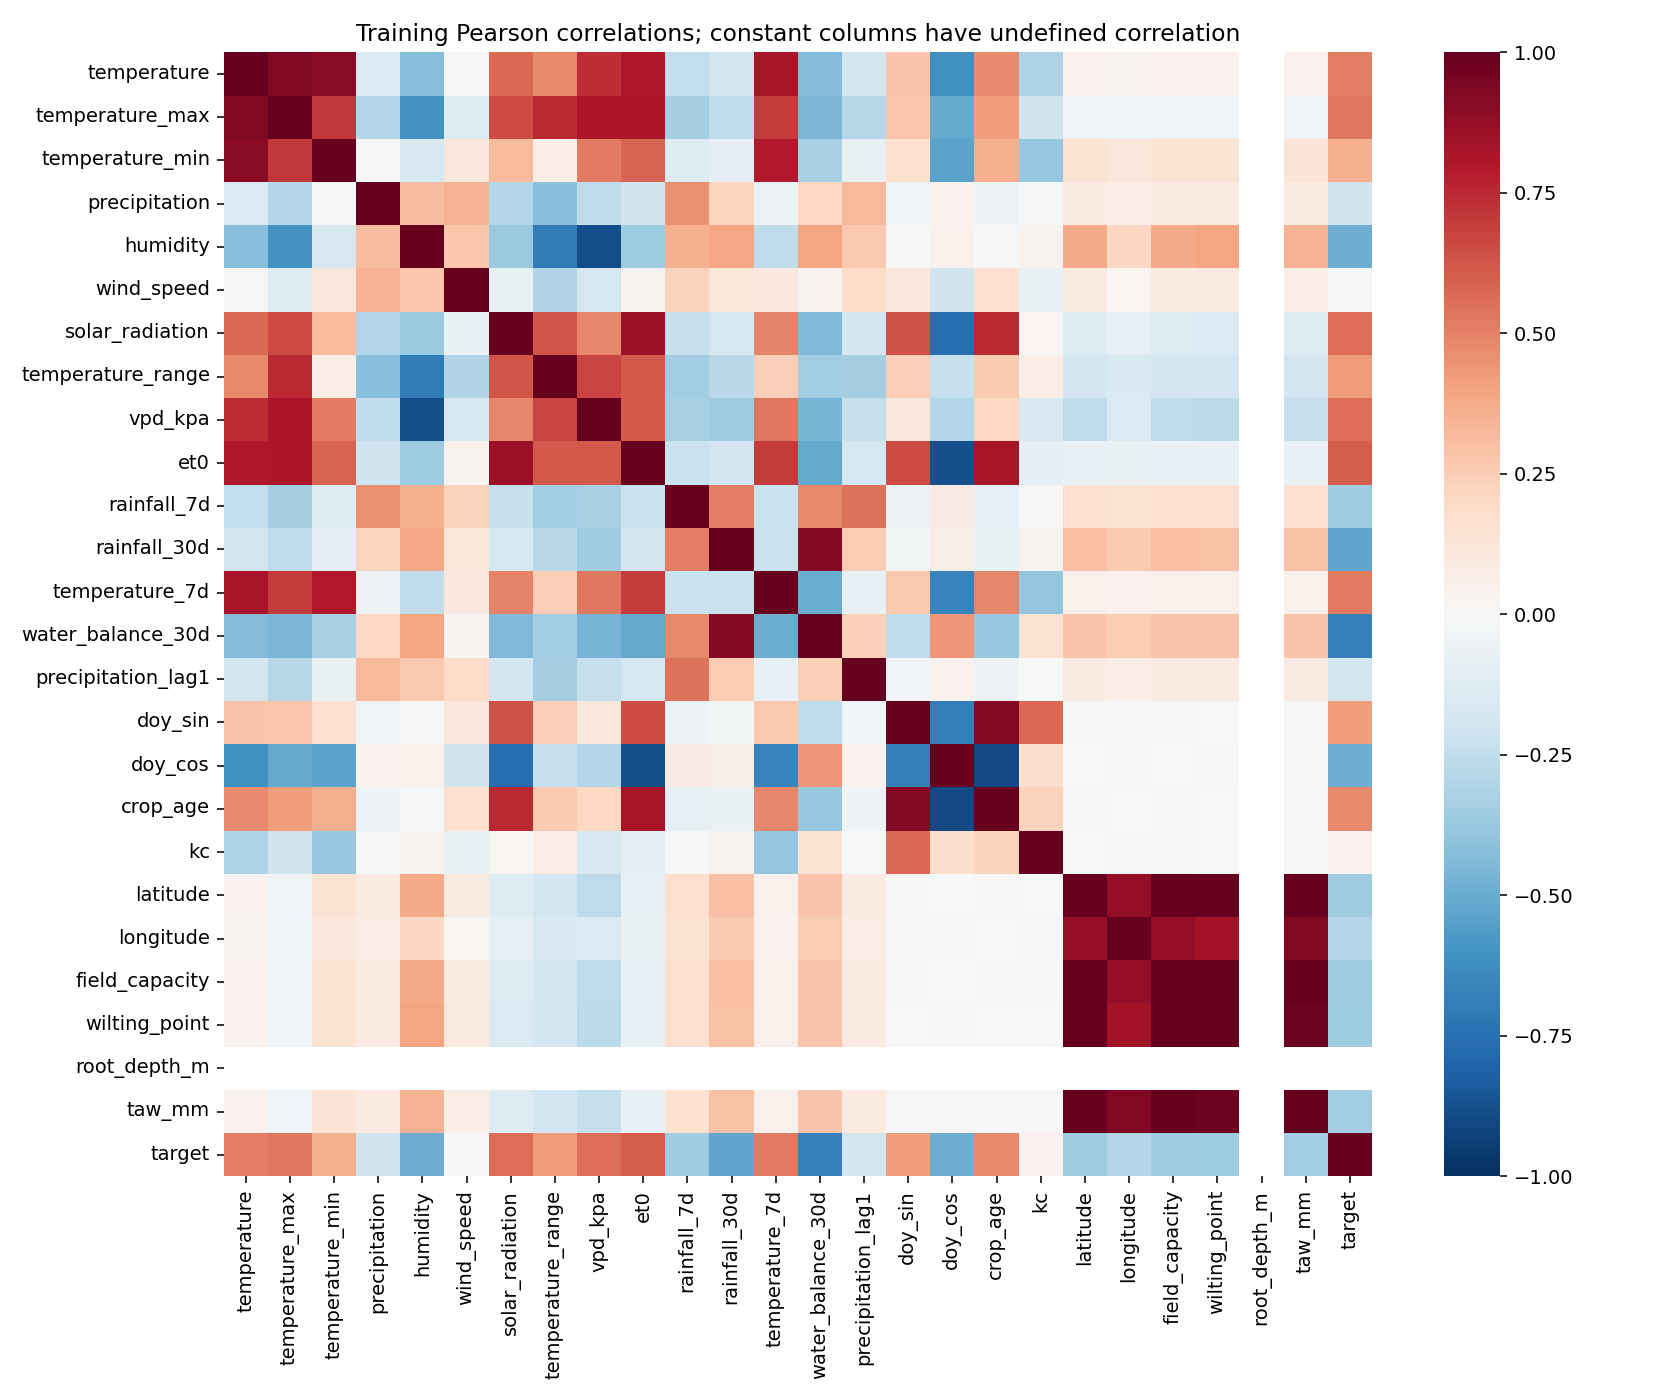

In [4]:
display(Image(filename=str(ARTIFACTS / 'eda/correlation.png')))

## Temporal patterns and weather relationships
Season gaps are left blank. Rainfall replenishes the modeled reservoir; ET removes water. The target also depends on assumed soil capacity and crop calendar.

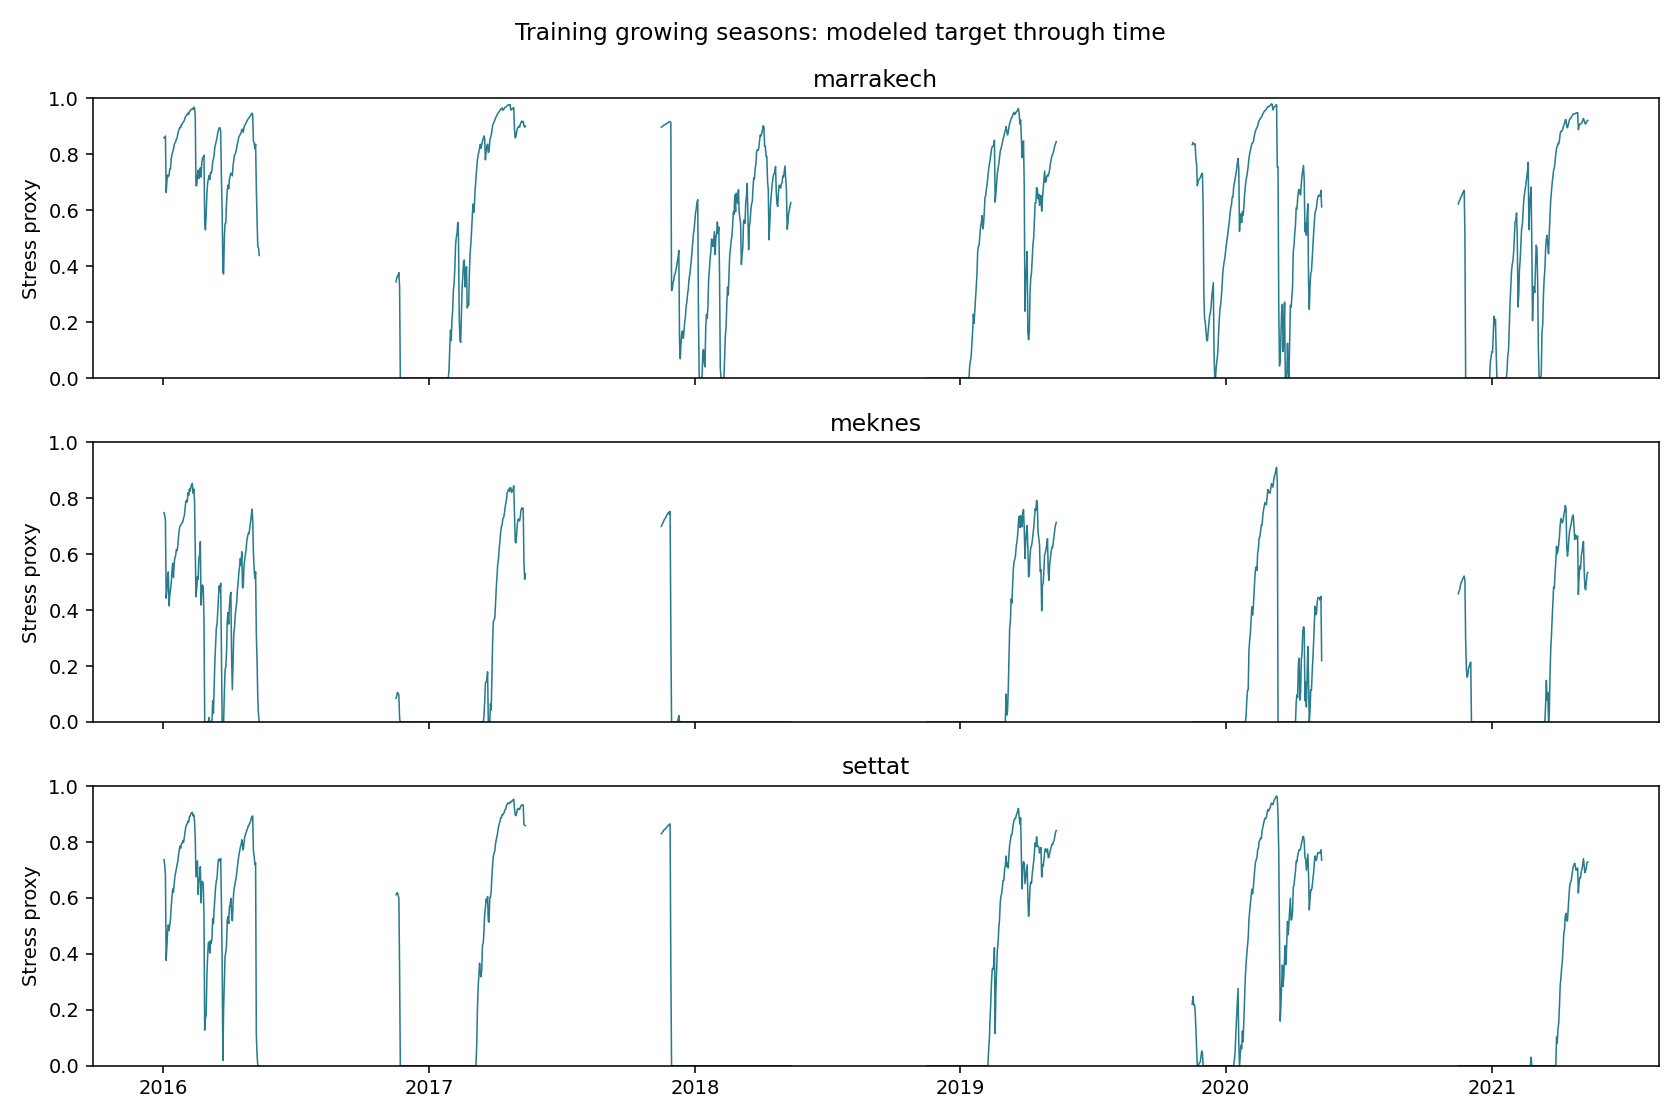

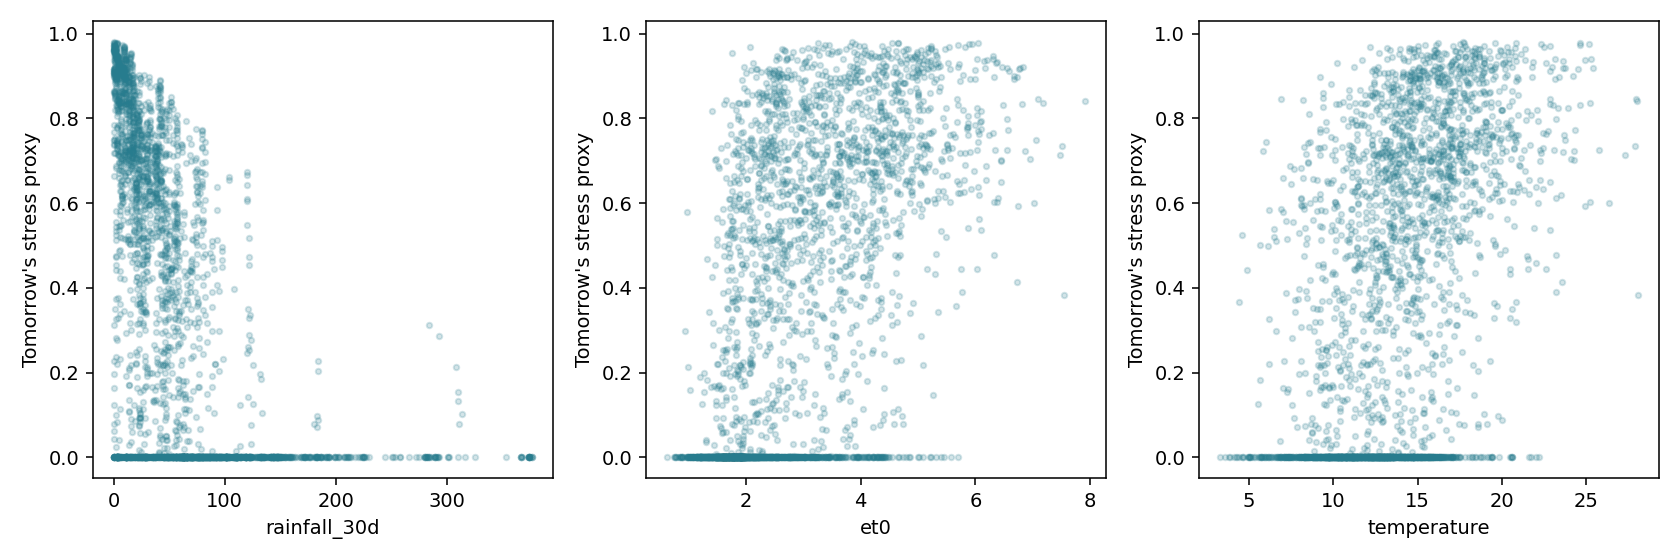

In [5]:
display(Image(filename=str(ARTIFACTS / 'eda/time_series.png')))
display(Image(filename=str(ARTIFACTS / 'eda/relationships.png')))

## Outlier analysis
IQR fences are descriptive flags, not deletion rules. Rainfall is naturally skewed and bounded targets often have a point mass at zero. Physically valid extremes remain in the dataset.

In [6]:
display(pd.read_csv(ARTIFACTS / 'eda/iqr_outliers.csv', index_col=0))
training.boxplot(column=['temperature', 'humidity'], figsize=(6, 4))
plt.title('Training weather spread (different physical units)')
plt.show()

,0
temperature,41
precipitation,552
humidity,21
et0,20
rainfall_30d,149
target,0


/tmp/ipykernel_59309/526411158.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Interpretation limits
These are three grid-point weather series with scenario soil parameters, not replicated field trials. Serial dependence and site mixing reduce the effective sample size. Feature selection and model choices must remain independent of test outcomes. See `docs/methodology.md` for proxy assumptions and sources.